In [ ]:
###### pip install tensorflow opencv-python matplotlib seaborn pandas numpy scikit-learn

In [2]:
import os
import glob

import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [5]:
metadata = pd.read_csv("Datasets/HAM10000_metadata.csv")

In [7]:
metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [8]:
metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  str    
 1   image_id      10015 non-null  str    
 2   dx            10015 non-null  str    
 3   dx_type       10015 non-null  str    
 4   age           9958 non-null   float64
 5   sex           10015 non-null  str    
 6   localization  10015 non-null  str    
dtypes: float64(1), str(6)
memory usage: 547.8 KB


In [9]:
metadata.describe(include="all")

,lesion_id,image_id,dx,dx_type,age,sex,localization
count,10015,10015,10015,10015,9958.000000,10015,10015
unique,7470,10015,7,4,NaN,3,15
top,HAM_0003789,ISIC_0027419,nv,histo,NaN,male,back
freq,6,1,6705,5340,NaN,5406,2192
mean,NaN,NaN,NaN,NaN,51.863828,NaN,NaN
std,NaN,NaN,NaN,NaN,16.968614,NaN,NaN
min,NaN,NaN,NaN,NaN,0.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,40.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,50.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,65.000000,NaN,NaN


In [10]:
#Dataset Shape
print(metadata.shape)

(10015, 7)


In [11]:
metadata.columns

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization'], dtype='str')

In [12]:
#Missing Values
metadata.isnull().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

In [13]:
#Duplicate Images
metadata.duplicated().sum()

np.int64(0)

In [15]:
#Target Classes
metadata["dx"].unique()

<StringArray>
['bkl', 'nv', 'df', 'mel', 'vasc', 'bcc', 'akiec']
Length: 7, dtype: str

In [16]:
#Disease Counts
class_counts = metadata["dx"].value_counts()

print(class_counts)

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


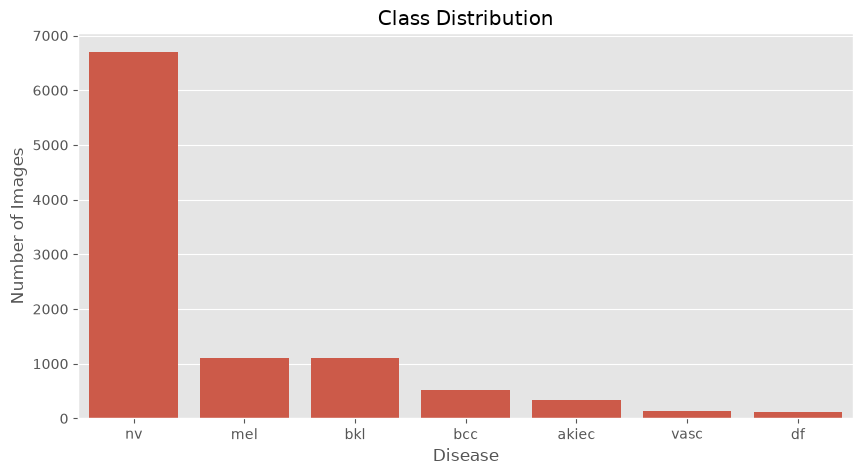

In [17]:
#Plot Class Distribution
plt.figure(figsize=(10,5))

sns.countplot(
    x="dx",
    data=metadata,
    order=metadata["dx"].value_counts().index
)

plt.title("Class Distribution")
plt.xlabel("Disease")
plt.ylabel("Number of Images")

plt.show()

In [18]:
#Disease Names
disease_names = {
    "nv":"Melanocytic Nevus",
    "mel":"Melanoma",
    "bcc":"Basal Cell Carcinoma",
    "akiec":"Actinic Keratosis",
    "bkl":"Benign Keratosis",
    "df":"Dermatofibroma",
    "vasc":"Vascular Lesion"
}

metadata["Disease"] = metadata["dx"].map(disease_names)

In [19]:
metadata[["dx","Disease"]].head()

,dx,Disease
0,bkl,Benign Keratosis
1,bkl,Benign Keratosis
2,bkl,Benign Keratosis
3,bkl,Benign Keratosis
4,bkl,Benign Keratosis


In [24]:
#Read Images
image_paths = {}

folders = [
    "Datasets/HAM10000_images_part_1",
    "Datasets/HAM10000_images_part_2"
]

for folder in folders:

    
    search_pattern = os.path.join(folder, "*.jpg")

   
    all_images = glob.glob(search_pattern)

    
    for image_path in all_images:

        
        file_name = os.path.basename(image_path)

        
        image_id = os.path.splitext(file_name)[0]

        
        image_paths[image_id] = image_path

In [25]:
metadata["path"] = metadata["image_id"].map(image_paths)

In [26]:
metadata[["image_id","path"]].head()

,image_id,path
0,ISIC_0027419,Datasets/HAM10000_images_part_1/ISIC_0027419.jpg
1,ISIC_0025030,Datasets/HAM10000_images_part_1/ISIC_0025030.jpg
2,ISIC_0026769,Datasets/HAM10000_images_part_1/ISIC_0026769.jpg
3,ISIC_0025661,Datasets/HAM10000_images_part_1/ISIC_0025661.jpg
4,ISIC_0031633,Datasets/HAM10000_images_part_2/ISIC_0031633.jpg


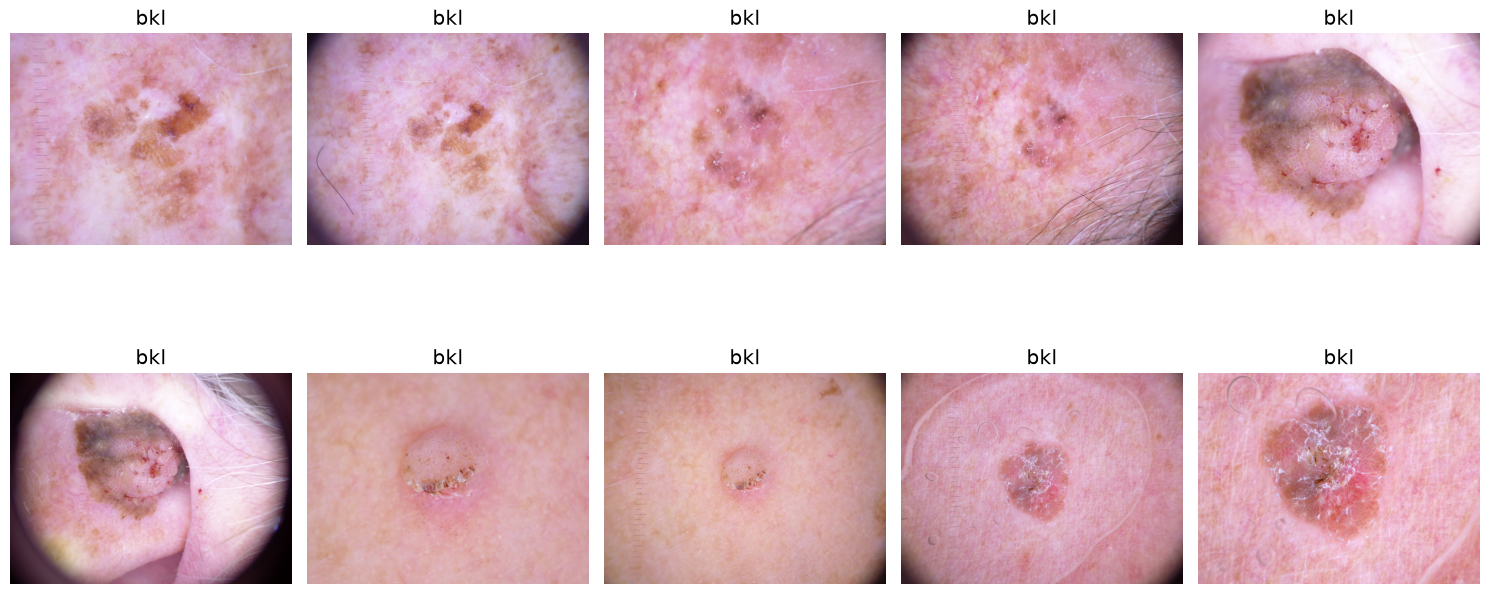

In [27]:
#Display Sample Images
plt.figure(figsize=(15,8))

for i in range(10):

    plt.subplot(2,5,i+1)

    image = cv2.imread(metadata.iloc[i]["path"])
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.imshow(image)

    plt.title(metadata.iloc[i]["dx"])

    plt.axis("off")

plt.tight_layout()

plt.show()

In [28]:
#Image Resolution Analysis
widths = []
heights = []

for path in metadata["path"]:

    image = cv2.imread(path)

    h, w = image.shape[:2]

    heights.append(h)

    widths.append(w)

In [29]:
metadata["Height"] = heights
metadata["Width"] = widths

In [30]:
metadata[["Height","Width"]].describe()

,Height,Width
count,10015.0,10015.0
mean,450.0,600.0
std,0.0,0.0
min,450.0,600.0
25%,450.0,600.0
50%,450.0,600.0
75%,450.0,600.0
max,450.0,600.0


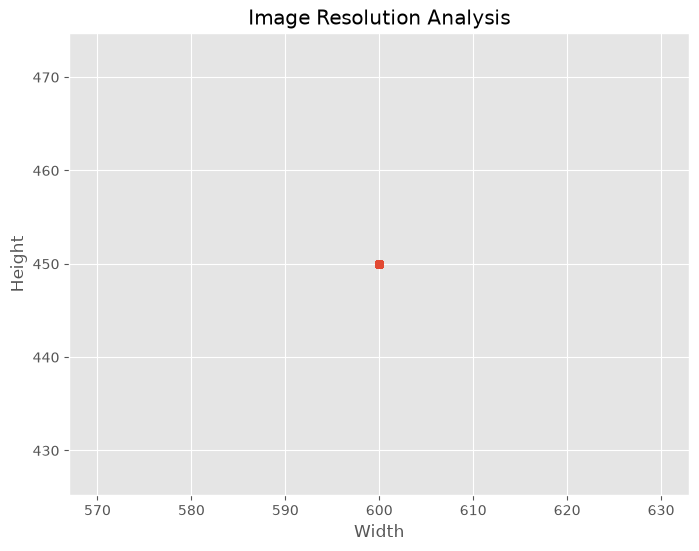

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(metadata["Width"], metadata["Height"], alpha=0.4)

plt.xlabel("Width")

plt.ylabel("Height")

plt.title("Image Resolution Analysis")

plt.show()

In [32]:
#Split the Dataset
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    metadata,
    test_size=0.30,
    stratify=metadata["dx"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["dx"],
    random_state=42
)

print("Training:", train_df.shape)
print("Validation:", val_df.shape)
print("Testing:", test_df.shape)

Training: (7010, 11)
Validation: (1502, 11)
Testing: (1503, 11)
